# LDA with gensim and spaCy

## Setup

In [14]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/DataScience/headlines-topic-modeling'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -qq gensim
!pip install pyLDAvis -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.5 MB/s eta 0:00:00


In [15]:
import numpy as np
import pandas as pd

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import Phrases
from gensim.models.phrases import Phraser

#spacy
import spacy
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt

#warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Preparing the data

In [6]:
pd.set_option('display.max_colwidth', None)
headlines = pd.read_csv('/content/abcnews-date-text.csv')
headlines

,publish_date,headline_text
0,20030219,aba decides against community broadcasting licence
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
1244179,20211231,two aged care residents die as state records 2;093
1244180,20211231,victoria records 5;919 new cases and seven deaths
1244181,20211231,wa delays adopting new close contact definition
1244182,20211231,western ringtail possums found badly dehydrated in heatwave


In [7]:
headlines['year'] = headlines['publish_date'] // 10000
headlines['month'] = (headlines['publish_date'] // 100) % 100
headlines['months_since_2003'] = (headlines['year'] - 2003) * 12 + headlines['month']
headlines = headlines.drop(['year', 'month'], axis=1)
headlines

,publish_date,headline_text,months_since_2003
0,20030219,aba decides against community broadcasting licence,2
1,20030219,act fire witnesses must be aware of defamation,2
2,20030219,a g calls for infrastructure protection summit,2
3,20030219,air nz staff in aust strike for pay rise,2
4,20030219,air nz strike to affect australian travellers,2
...,...,...,...
1244179,20211231,two aged care residents die as state records 2;093,228
1244180,20211231,victoria records 5;919 new cases and seven deaths,228
1244181,20211231,wa delays adopting new close contact definition,228
1244182,20211231,western ringtail possums found badly dehydrated in heatwave,228


In [9]:
X_train, X_test = train_test_split(headlines, train_size=100000, random_state=111, stratify=headlines['months_since_2003'])
X_train = X_train.reset_index()
X_train = X_train.drop('index', axis=1)
X_train

,publish_date,headline_text,months_since_2003
0,20170908,turnbull promises to step up australias engagement in pacific,177
1,20071220,police appeal for safe driving over holiday period,60
2,20060720,fast food worker not put off by shooting,43
3,20111013,readfearn carbon price pulls through anti climate change furor,106
4,20130415,brenton kroen from waikerie,124
...,...,...,...
99995,20190317,tasmanian aboriginal food business spreading culture,195
99996,20101226,sydney to hobart start review,96
99997,20091111,treasurer kevin foley tells 891 of 10m,83
99998,20100113,bumper tourism season,85


## Text preprocessing w/ bigrams and trigrams

In [12]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    texts_out = []

    for doc in nlp.pipe(texts, batch_size=2000, n_process=-1):

        new_text = [t.lemma_ for t in doc if t.pos_ in allowed_postags
                    and not t.is_stop and len(t.lemma_) > 2 and t.is_alpha]
        texts_out.append(new_text)

    return texts_out

In [19]:
data_tokens = lemmatization(X_train['headline_text'])
print(data_tokens[0][0:20])

['turnbull', 'promise', 'step', 'australias', 'engagement']


In [20]:
bigram = Phrases(data_tokens, min_count=5, threshold=100)
trigram = Phrases(bigram[data_tokens], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

clean_docs = [trigram_mod[bigram_mod[doc]] for doc in data_tokens]

## Determining optimal # of topics

In [21]:
id2word = corpora.Dictionary(clean_docs)
id2word.filter_extremes(no_below=10, no_above=.4, keep_n=100000)
corpus = [id2word.doc2bow(text) for text in clean_docs]

In [22]:
id2word.save(f'{folder_path}/headlines_dictionary.dict')

In [35]:
topic_range = [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
coherence_vals = []

for k in topic_range:
  print(f"Testing K={k}...")

  lda_topic_range = gensim.models.LdaModel(
                    corpus=corpus,
                    id2word=id2word,
                    num_topics=k,
                    random_state = 111,
                    update_every=1,
                    chunksize=10000,
                    passes=5,
                    alpha='auto',
                    eta='auto'
                    )

  cm = CoherenceModel(model=lda_topic_range, texts=clean_docs, dictionary=id2word, coherence='c_v')
  coherence_vals.append(cm.get_coherence())

Testing K=20...
Testing K=30...
Testing K=40...
Testing K=50...
Testing K=60...
Testing K=70...
Testing K=80...
Testing K=90...
Testing K=100...
Testing K=110...
Testing K=120...


## Visualizing the coherence scores

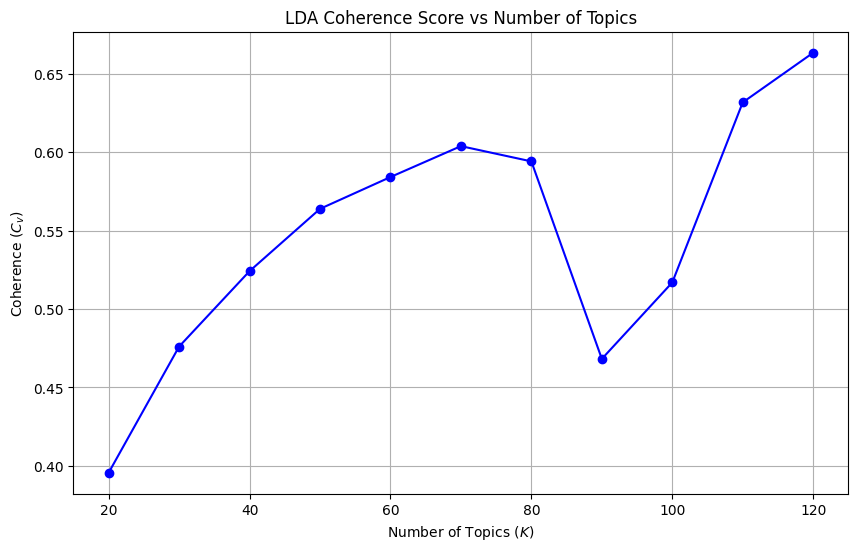

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(topic_range, coherence_vals, marker='o', color='b', linestyle='-')
plt.title("LDA Coherence Score vs Number of Topics")
plt.xlabel("Number of Topics ($K$)")
plt.ylabel("Coherence ($C_v$)")
plt.grid(True)
plt.show()

## Training the model

In [38]:
lda_70 = gensim.models.LdaModel(
          corpus=corpus,
          id2word=id2word,
          num_topics=70,
          random_state = 111,
          update_every=1,
          chunksize=10000,
          passes=10,
          alpha='auto',
          eta='auto'
          )

cm = CoherenceModel(model=lda_70, texts=clean_docs, dictionary=id2word, coherence='c_v')
print(cm.get_coherence())

0.4759472549788886


In [42]:
lda_70.save(f'{folder_path}/news_lda_70_model.model')

## Visualizing the trained model

In [41]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_70, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
14    -0.121576  0.452296       1        1  2.499518
11     0.114809 -0.502731       2        1  2.433136
2     -0.109435 -0.386381       3        1  2.395449
10     0.539685 -0.005039       4        1  2.333096
7      0.045929  0.274740       5        1  2.098794
...         ...       ...     ...      ...       ...
1     -0.522657  0.050846      66        1  0.932387
69    -0.486269 -0.120178      67        1  0.928110
31    -0.350752 -0.145001      68        1  0.918507
8     -0.280294 -0.432209      69        1  0.912073
62    -0.425794  0.171359      70        1  0.842454

[70 rows x 5 columns], topic_info=              Term         Freq        Total Category  logprob  loglift
135            man  2743.000000  2743.000000  Default  30.0000  30.0000
131            say  2132.000000  2132.000000  Default  29.0000  29.0000
127         charge  1883.000000  1883.000000  Default  28.0000  28.0000
98            plan  1964.000000  1964.000000  Default  27.0000  27.0000
439            win  1469.000000  1469.000000  Default  26.0000  26.0000
...            ...          ...          ...      ...      ...      ...
4221       setback    26.914372    27.997271  Topic70  -4.7277   4.7372
4116          aged    26.859936    27.942835  Topic70  -4.7298   4.7371
2652  preselection    26.041080    27.123980  Topic70  -4.7607   4.7359
2196      boundary    25.978818    27.061717  Topic70  -4.7631   4.7358
2134          bolt    24.709812    25.792711  Topic70  -4.8132   4.7337

[2215 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
3240     47  0.977688    abalone
560      62  0.984833    abandon
1079     62  0.983431   abattoir
1435     57  0.980564  abduction
3892      2  0.896482      abetz
...     ...       ...        ...
250      61  0.997263      young
1114      1  0.996394      youth
575      22  0.990454   zimbabwe
1690     44  0.993507       zone
1286     61  0.973680        zoo

[2239 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[15, 12, 3, 11, 8, 29, 66, 61, 7, 57, 20, 1, 53, 19, 34, 33, 42, 51, 10, 21, 25, 55, 31, 47, 45, 49, 18, 41, 13, 65, 69, 60, 17, 67, 44, 28, 58, 30, 40, 26, 62, 5, 22, 27, 23, 35, 68, 4, 14, 6, 59, 36, 24, 43, 46, 64, 48, 50, 39, 16, 37, 52, 54, 56, 38, 2, 70, 32, 9, 63])